# Assignment 1
**Credits**: Federico Ruggeri, Eleonora Mancini, Paolo Torroni

**Keywords**: Sexism Detection, Multi-class Classification, RNNs, Transformers, Huggingface



# Contact
For any doubt, question, issue or help, you can always contact us at the following email addresses:

Teaching Assistants:

- Federico Ruggeri -> federico.ruggeri6@unibo.it
- Eleonora Mancini -> e.mancini@unibo.it

Professor:
- Paolo Torroni -> p.torroni@unibo.it

# Introduction
You are asked to address the [EXIST 2023 Task 2](https://clef2023.clef-initiative.eu/index.php?page=Pages/labs.html#EXIST) on sexism detection.

## Problem Definition

This task aims to categorize the sexist messages according to the intention of the author in one of the following categories: (i) direct sexist message, (ii) reported sexist message and (iii) judgemental message.

### Examples:

#### DIRECT 
The intention was to write a message that is sexist by itself or incites to be sexist, as in:

''*A woman needs love, to fill the fridge, if a man can give this to her in return for her services (housework, cooking, etc), I don’t see what else she needs.*''

#### REPORTED
The intention is to report and share a sexist situation suffered by a woman or women in first or third person, as in:

''*Today, one of my year 1 class pupils could not believe he’d lost a race against a girl.*''

#### JUDGEMENTAL
The intention was to judge, since the tweet describes sexist situations or behaviours with the aim of condemning them.

''*As usual, the woman was the one quitting her job for the family’s welfare…*''

In [1]:
# # Package requirements
# ! pip install --upgrade pip
# ! pip install emoji pandas nltk gensim numpy tensorflow matplotlib scikit-learn

In [2]:
# Standard library
import os
import re
import json
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import pandas as pd
import emoji
import gensim
import gensim.downloader as gloader
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from tensorflow.keras.preprocessing.text import Tokenizer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf

# Typing
from typing import List, Dict, Tuple, Set


2025-12-16 14:12:38.969771: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# [Task 1 - 1.0 points] Corpus

We have preparared a small version of EXIST dataset in our dedicated [Github repository](https://github.com/lt-nlp-lab-unibo/nlp-course-material/tree/main/2025-2026/Assignment%201/data).

Check the `A1/data` folder. It contains 3 `.json` files representing `training`, `validation` and `test` sets.


### Dataset Description
- The dataset contains tweets in both English and Spanish.
- There are labels for multiple tasks, but we are focusing on **Task 2**.
- For Task 2, labels are assigned by six annotators.
- The labels for Task 2 represent whether the tweet is non-sexist ('-') or its sexist intention ('DIRECT', 'REPORTED', 'JUDGEMENTAL').







### Example

```
    "203260": {
        "id_EXIST": "203260",
        "lang": "en",
        "tweet": "ik when mandy says “you look like a whore” i look cute as FUCK",
        "number_annotators": 6,
        "annotators": ["Annotator_473", "Annotator_474", "Annotator_475", "Annotator_476", "Annotator_477", "Annotator_27"],
        "gender_annotators": ["F", "F", "M", "M", "M", "F"],
        "age_annotators": ["18-22", "23-45", "18-22", "23-45", "46+", "46+"],
        "labels_task1": ["YES", "YES", "YES", "NO", "YES", "YES"],
        "labels_task2": ["DIRECT", "DIRECT", "REPORTED", "-", "JUDGEMENTAL", "REPORTED"],
        "labels_task3": [
          ["STEREOTYPING-DOMINANCE"],
          ["OBJECTIFICATION"],
          ["SEXUAL-VIOLENCE"],
          ["-"],
          ["STEREOTYPING-DOMINANCE", "OBJECTIFICATION"],
          ["OBJECTIFICATION"]
        ],
        "split": "TRAIN_EN"
      }
    }
```

### Instructions
1. **Download** the `A1/data` folder.
2. **Load** the three JSON files and encode them as ``pandas.DataFrame``.
3. **Aggregate labels** for Task 2 using majority voting and store them in a new dataframe column called `label`. Items without a clear majority will be removed from the dataset.
4. **Filter the DataFrame** to keep only rows where the `lang` column is `'en'`.
5. **Remove unwanted columns**: Keep only `id_EXIST`, `lang`, `tweet`, and `label`.
6. **Encode the `label` column**: Use the following mapping

```
{
    '-': 0,
    'DIRECT': 1,
    'JUDGEMENTAL': 2,
    'REPORTED': 3
}
```

In [3]:
# Load and encode the jsons
train_df = pd.DataFrame(json.load(open('./data/training.json'))).transpose()
test_df = pd.DataFrame(json.load(open('./data/test.json'))).transpose()
val_df = pd.DataFrame(json.load(open('./data/validation.json'))).transpose()
dfs = [train_df, val_df, test_df]

print("Before:", train_df.shape, val_df.shape, test_df.shape)

for i, df in enumerate(dfs):
    # Aggregate labels by majority vote, only keep rows with unique majority
    majority_labels = []
    for labels in df["labels_task2"]:
        c = Counter(labels).most_common(2)
        if len(c)==1:
            majority_labels.append(c[0][0])
        elif c[1][1] < c[0][1]:
            majority_labels.append(c[0][0])
        else:
            majority_labels.append(None)
    df["label"] = majority_labels
    df = df.dropna(subset=["label"]).reset_index(drop=True)

    # Filter rows with language "en"
    df = df[df["lang"]=="en"].reset_index(drop=True)
    df = df[["id_EXIST", "lang", "tweet", "label"]]

    # Encode labels as integers
    label_mapping = {"-":0, "DIRECT":1, "JUDGEMENTAL":2, "REPORTED":3}
    reverse_mapping = {v: k for k, v in label_mapping.items()}  # TODO: utile per debug ma togliere dopo
    df["label"] = df["label"].map(label_mapping)

    dfs[i] = df # NOTE: we have to do this otherwise the changes won't persist


train_df, val_df, test_df = dfs
print("After: ", train_df.shape, val_df.shape, test_df.shape)

Before: (6920, 11) (726, 11) (312, 11)
After:  (2873, 4) (150, 4) (280, 4)


# [Task2 - 0.5 points] Data Cleaning
In the context of tweets, we have noisy and informal data that often includes unnecessary elements like emojis, hashtags, mentions, and URLs. These elements may interfere with the text analysis.



### Instructions
- **Remove emojis** from the tweets.
- **Remove hashtags** (e.g., `#example`).
- **Remove mentions** such as `@user`.
- **Remove URLs** from the tweets.
- **Remove special characters and symbols**.
- **Remove specific quote characters** (e.g., curly quotes).
- **Perform lemmatization** to reduce words to their base form.

In [4]:
# Download required NLTK data
# NOTE: this is mostly from the lab, mayeb it's not the most efficient way
os.makedirs("nltk_data", exist_ok=True)
nltk.download('omw-1.4', download_dir="./nltk_data")
nltk.download('wordnet', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger', download_dir="./nltk_data")
nltk.download('averaged_perceptron_tagger_eng', download_dir="./nltk_data")
nltk.download('punkt_tab', download_dir="./nltk_data")
nltk.data.path.append("./nltk_data")

lemmatizer = WordNetLemmatizer()

def pos2wordnet_tag(treebank_tag: str) -> str:
    match treebank_tag[0]:
        case "J":   return wordnet.ADJ
        case "V":   return wordnet.VERB
        case "N":   return wordnet.NOUN
        case "R":   return wordnet.ADV
        case _:     return wordnet.NOUN

def token_lemma(text: str) -> str:
    """
    Tokenize the text, then lemmatize the tokens and then merge the lemmatized tokens into a text
    """
    tokens = word_tokenize(text)    # usese recommended NLTK tokenizer
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [
        lemmatizer.lemmatize(tok.lower(), pos2wordnet_tag(pos))
        for tok, pos in tagged_tokens
    ]
    return " ".join(lemmatized_tokens)

# NOTE: we replace chars with space to avoid merging words during the process, the tokenizer will take care of extra spaces.
def clean_text(text, patterns):
    
    # 1) Remove emojis
    # NOTE: we asked the tutors and they said that it is meant to remove only visible emojis, not text-based ones. We used the emoji library for completeness.
    # NOTE: the tutor said that we could delete or replace with text, since there are already text emoji we can't handle it could be interesting to replace them with text in order to cover them properly. On the other hand text emoji are rare in the dataset and are for sure used in a different way.
    # NOTE; we don't include the regex for emojis here since we are using the emoji library and it is more efficient and complete.
    text = emoji.replace_emoji(text, replace=' ')    
    
    # Remove other patterns
    for pattern in patterns:
        text = pattern.sub(' ', text) 
    
    # Tokenize, lemmatize and merge
    return token_lemma(text)

[nltk_data] Downloading package omw-1.4 to ./nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to ./nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     ./nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to ./nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
# NOTE: 1 big regex for all patterns would be more efficient, but here we prefer to keep them separate for clarity

patterns = [
    
    # 2) Hashtags
    re.compile(r'#\w+'),
    
    # 3) Mentions
    re.compile(r'@\w+'),
    
    # 4) URLs
    re.compile(r'https?://[^\s]+'), 
    
    # 6) Specific quotes characters, i assume not the regular ones (e.g. " ' )
    # NOTE: we do this here explicitely in order not to implicitly remove them with the special characters pattern
    re.compile(r'[“”‘’«»`´]'), 
    
    # 5) Special characters and symbols
    # NOTE: we asked the tutors as it was ambiguous and they said they meant all non-alphanumeric characters, considering also quotes, parentheses, punctuation, etc.
    re.compile(r'[^a-zA-Z0-9\s]'),

]

for i, df in enumerate(dfs):
    df['cleaned_tweet'] = df["tweet"].apply(lambda text: clean_text(text, patterns))
    
    # TODO: only for train set, maybe apply more complex cleaning:
    # 1) remove noisy chars due to simple removal
    # 2) compression of repeated punctuation
    # 3) MAYBE: html tags, mnore complex and noisy patterns (es. 10%-)
    if i==0: 
        pass
        
    dfs[i] = df    

display(train_df[["tweet", "cleaned_tweet"]])

,tweet,cleaned_tweet
0,FFS! How about laying the blame on the bastard...,ffs how about lay the blame on the bastard who...
1,Writing a uni essay in my local pub with a cof...,write a uni essay in my local pub with a coffe...
2,@UniversalORL it is 2021 not 1921. I dont appr...,it be 2021 not 1921 i dont appreciate that on ...
3,@GMB this is unacceptable. Use her title as yo...,this be unacceptable use her title a you do fo...
4,‘Making yourself a harder target’ basically bo...,make yourself a hard target basically boil dow...
...,...,...
2868,@ShefVaidya Ma'am if I say that you look like ...,ma be if i say that you look like a whore woul...
2869,idk why y’all bitches think having half your a...,idk why y all bitch think have half your as ha...
2870,This has been a part of an experiment with @Wo...,this have be a part of an experiment with what...
2871,"""Take me already"" ""Not yet. You gotta be ready...",take me already not yet you get ta be ready i ...


In [6]:
def build_word_listing(df):
    vocab = set()
    tokens_vec=[]
    for text in df["cleaned_tweet"]:
        # NOTE: we use split since they were already tokenized and then jointed with spaces
        tokens = text.split(" ")
        vocab.update(tokens)
        tokens_vec.append(tokens)
    return sorted(vocab), tokens_vec

word_listing_train, train_corpus = build_word_listing(train_df)
word_listing_val, val_corpus = build_word_listing(val_df)
word_listing_test, test_corpus = build_word_listing(test_df)

# [Task 3 - 0.5 points] Text Encoding
To train a neural sexism classifier, you first need to encode text into numerical format.




### Instructions

* Embed words using **GloVe embeddings**.
* You are **free** to pick any embedding dimension.





### What about OOV tokens?
   * All the tokens in the **training** set that are not in GloVe **must** be added to the vocabulary.
   * For the remaining tokens (i.e., OOV in the validation and test sets), you have to assign them a **special token** (e.g., ``<UNK>``) and a **static** embedding.
   * You are **free** to define the static embedding using any strategy (e.g., random, neighbourhood, etc...)



### More about OOV

For a given token:

* **If in train set**: add to vocabulary and assign an embedding (use GloVe if token in GloVe, custom embedding otherwise).
* **If in val/test set**: assign special token if not in vocabulary and assign custom embedding.

Your vocabulary **should**:

* Contain all tokens in train set; or
* Union of tokens in train set and in GloVe $\rightarrow$ we make use of existing knowledge!

In [7]:
# Hyperparams
WINDOW_SIZE = 5
EMBEDDING_DIMENSION = 50
OOV_TOKEN = "<OOV>"

In [8]:
# FUNCTIONS

def load_embedding_model(
    model_type: str,
    embedding_dimension: int = 50
) -> gensim.models.keyedvectors.KeyedVectors:
    
    """
    Load pre-trained embedding model (Word2Vec, GloVe, FastText).

    :param model_type: 'word2vec', 'glove', or 'fasttext'
    :param embedding_dimension: embedding size (only used for GloVe)
    :return: gensim KeyedVectors object
    """
    
    types = {
        "word2vec" : "word2vec-google-news-300",
        "glove" : f"glove-wiki-gigaword-{embedding_dimension}",
        "fasttext" : "fasttext-wiki-news-subwords-300"
    }
    
    model_type_lower = model_type.strip().lower()
    if model_type_lower not in types.keys():
        raise ValueError(f"Unsupported embedding model type. Use {', '.join(list(types.keys()))}")
    else:
        path = types[model_type_lower]
        
    try:
        return gloader.load(path)
    except ValueError as e:
        raise ValueError("Failed to load embedding. Check dimension compatibility.") from e


def build_alacarte_transform(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    window_size: int = 5
) -> np.ndarray:
    
    """
    Compute A-La-Carte transformation matrix from a training corpus.

    Reference:
    Khodak, M., Saunshi, N., & Liang, P. (2018).
    "A La Carte Embedding: Cheap but Effective Induction of Semantic Feature Vectors."
    ACL 2018.

    :param train_corpus: tokenized training corpus
    :param embedding_model: pre-trained embedding model
    :param window_size: size of context window for each word
    :return: transformation matrix A (embedding_dim x embedding_dim)
    """
    
    context_vectors = {}
    context_counts = {}

    # Build averaged context vectors for each word
    for sentence in train_corpus:
        for i, word in enumerate(sentence):
            
            # Skip words without a pretrained embedding as they cannot serve as regression targets
            if word not in embedding_model:
                continue 
            
            # Collect embeddings for neighboring [+window_size, -window_size], excluding the current word
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            context = [embedding_model[w] for w in sentence[start:i] + sentence[i+1:end] if w in embedding_model]
            if context:
                avg_ctx = np.mean(context, axis=0)
                if word in context_vectors:
                    context_vectors[word] += avg_ctx
                    context_counts[word] += 1
                else:
                    context_vectors[word] = avg_ctx
                    context_counts[word] = 1

    # Normalize by occurrences
    for word in context_vectors:
        context_vectors[word] /= context_counts[word]

    U = np.array([context_vectors[w] for w in context_vectors])
    V = np.array([embedding_model[w] for w in context_vectors])
    
    # Linear regression to find transformation matrix
    A = np.linalg.lstsq(U, V, rcond=None)[0].T
    return A


def build_vocabulary_train_union(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors
) -> Tuple[Set[str], Set[str]]:
    
    """
    Union of training tokens and embedding vocabulary.

    :return: (vocabulary union, training tokens)
    """
    
    train_tokens = set(tok for sent in train_corpus for tok in sent)
    embedding_vocab = set(embedding_model.index_to_key)
    vocabulary = train_tokens | embedding_vocab
    return vocabulary, train_tokens


def create_custom_embeddings_for_train_oov(
    train_corpus: List[List[str]],
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    transform_matrix: np.ndarray
) -> Dict[str, np.ndarray]:
    
    """
    Generate embeddings for training OOV tokens using A-La-Carte.
    
    Reference:
    Khodak, M., Saunshi, N., & Liang, P. (2018).
    "A La Carte Embedding: Cheap but Effective Induction of Semantic Feature Vectors."
    ACL 2018.

    :return: dict mapping OOV token -> embedding vector
    """
    
    embedding_dim = embedding_model.vector_size
    train_tokens = set(tok for sent in train_corpus for tok in sent)
    train_oov = train_tokens - set(embedding_model.index_to_key)

    # Collect contexts for OOV tokens
    oov_contexts = defaultdict(list)
    for sentence in train_corpus:
        for word in sentence:
            if word in train_oov:
                context = [w for w in sentence if w != word and w in embedding_model]
                if context:
                    oov_contexts[word].append(context)

    # Compute the embedding based on OOV contexts, if any
    custom_embeddings = {}
    for word in train_oov:
        if oov_contexts[word]:
            avg_vecs = [np.mean([embedding_model[w] for w in ctx], axis=0) for ctx in oov_contexts[word]]
            final_context = np.mean(avg_vecs, axis=0)
            custom_embeddings[word] = transform_matrix @ final_context
        else:
            custom_embeddings[word] = np.random.normal(0, 0.1, embedding_dim)

    return custom_embeddings


def build_tokenizer_with_vocabulary(
    vocabulary: Set[str],
    train_tokens: Set[str],
    oov_token: str = "<OOV>"
) -> Tokenizer:
    
    """
    Build a Keras tokenizer from a fixed vocabulary.
    Fits on train_tokens first, then statically adds remaining vocabulary tokens.
    
    :param vocabulary: Complete vocabulary (train + embedding tokens)
    :param train_tokens: Tokens from training corpus only
    :param oov_token: Token to use for out-of-vocabulary words
    :return: Configured tokenizer with full vocabulary
    """
    
    tokenizer = Tokenizer(oov_token=oov_token)
    
    # Dynamic tokenization: fit on training tokens
    # NOTE: This automatically adds OOV token at index 1 and reserves index 0 for padding
    tokenizer.fit_on_texts([' '.join(train_tokens)]) 
    
    # Static addition: add embedding tokens not in training set
    # NOTE: We add these statically because GloVe tokens may contain special chars
    # (punctuation, URLs, etc.) that Keras tokenizer would split during fitting
    max_idx = max(tokenizer.word_index.values()) 
    for token in sorted(vocabulary - train_tokens):
        max_idx += 1
        tokenizer.word_index[token] = max_idx
    tokenizer.index_word = {idx: word for word, idx in tokenizer.word_index.items()}
    tokenizer.document_count = len(vocabulary)
    
    return tokenizer


def build_embedding_matrix(
    tokenizer: Tokenizer,
    embedding_model: gensim.models.keyedvectors.KeyedVectors,
    train_custom_embeddings: Dict[str, np.ndarray],
    oov_token: str = "<OOV>",
    verbose: bool = False,
    debug_dict: dict = None
) -> np.ndarray:
    """
    Construct embedding matrix for Keras model: pre-trained + custom embeddings.

    :return: embedding matrix (vocab_size x embedding_dim)
    """
    embedding_dim = embedding_model.vector_size
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    glove_count = 0
    custom_count = 0
    others_count = 0

    for word, idx in tokenizer.word_index.items():
        if word == oov_token:
            # OOV token gets a small random vector
            # NOTE: it will be updated at inference time by considering the context in the test/val batch
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            if verbose : print(f"[OOV]       idx={idx} -> random vector")
            if debug_dict is not None: debug_dict["OOV"]=word

        elif word in embedding_model:
            # Pre-trained embedding exists 
            embedding_matrix[idx] = embedding_model[word]
            glove_count += 1  
            if verbose : print(f"[PRE-TRAIN] idx={idx} '{word}' -> pre-trained embedding")
            if debug_dict is not None: debug_dict["PRE-TRAIN"]=word

        elif word in train_custom_embeddings:
            # Custom embedding available
            embedding_matrix[idx] = train_custom_embeddings[word]
            custom_count += 1 
            if verbose : print(f"[CUSTOM]    idx={idx} '{word}' -> custom embedding")
            if debug_dict is not None: debug_dict["CUSTOM"]=word

        else:
            # Word not found in any embedding source, assign random vector
            # NOTE: this shouldn't happen
            embedding_matrix[idx] = np.random.normal(0, 0.1, embedding_dim)
            others_count += 1
            if verbose : print(f"[ELSE]      idx={idx} '{word}' -> no embedding found, random vector")
            if debug_dict is not None: debug_dict["ELSE"]=word

    if verbose:
        print(f"Embedding matrix built: {glove_count} pre-trained, {custom_count} custom, {others_count} others")
        
    return embedding_matrix

In [9]:
# Load embedding model
embedding_model = load_embedding_model("glove", EMBEDDING_DIMENSION)

# Build A-La-Carte transformation matrix
A = build_alacarte_transform(train_corpus, embedding_model, window_size=WINDOW_SIZE)

# Create vocabulary union
vocabulary, train_tokens = build_vocabulary_train_union(train_corpus, embedding_model)

# Generate custom embeddings for training OOV tokens
train_custom_embeddings = create_custom_embeddings_for_train_oov(
    train_corpus, embedding_model, A
)

# Build tokenizer with full vocabulary
tokenizer = build_tokenizer_with_vocabulary(vocabulary, train_tokens, oov_token=OOV_TOKEN)
vocab_size = len(tokenizer.word_index) + 1 # +1 for index 0 for padding

print(f"Vocabulary size: {vocab_size}")

# Build embedding matrix
embedding_matrix = build_embedding_matrix(
    tokenizer, embedding_model, train_custom_embeddings, oov_token=OOV_TOKEN,
    verbose=False
)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

# NOTE: the test/val OOV will be handled at inference time thanks to the contexts of the batches

Vocabulary size: 400932
Embedding matrix shape: (400932, 50)


## Extra: visualization of embedding

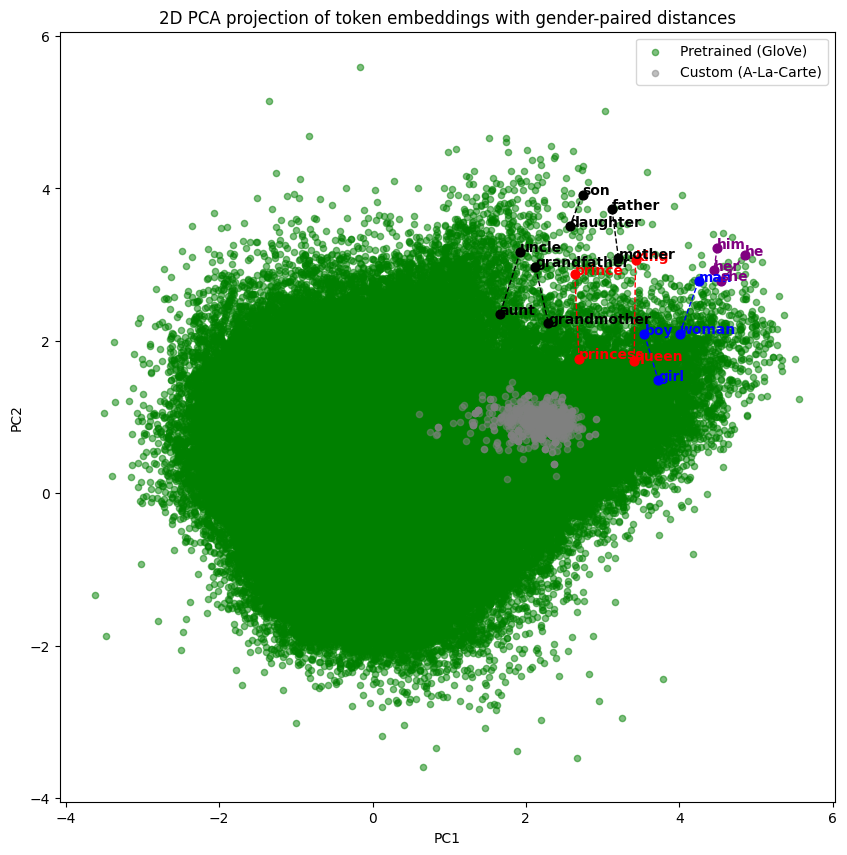

In [10]:
token_to_embedding = {word : embedding_matrix[idx] for word, idx in tokenizer.word_index.items()}
tokens = list(token_to_embedding.keys())
embeddings = np.array([token_to_embedding[t] for t in tokens])

# NOTE: the 3d reduction wasn't more informative so we kept only this one
pca_2d = PCA(n_components=2)
embeddings_2d = pca_2d.fit_transform(embeddings)
token_to_2d = {token: embeddings_2d[i] for i, token in enumerate(tokens)}

# Separate tokens into pretrained (from GloVe) and custom (A-La-Carte generated)
pretrained_tokens = set(embedding_model.index_to_key)
custom_tokens = set(train_custom_embeddings.keys())

# Get embeddings for each category
pretrained_coords = np.array([token_to_2d[t] for t in tokens if t in pretrained_tokens])
custom_coords = np.array([token_to_2d[t] for t in tokens if t in custom_tokens])

# Define gender-paired tuples
# TODO: add more and more informative
gender_pairs = (
    (("king", "queen"), ("prince", "princess")),
    (("man", "woman"), ("boy", "girl")),
    (("father", "mother"), ("son", "daughter"), ("grandfather", "grandmother"), ("uncle", "aunt")),
    (("he", "she"), ("him", "her")),
)
word_groups = [(
    word 
    for pair in group 
    for word in pair 
) for group in gender_pairs]

# Define up to 10 distinct colors for the groups 
group_colors = [ 
    "red", "blue", "black", "purple", "orange",
    "pink", "cyan", "magenta", "black", "yellow",
    "brown" 
]

plt.figure(figsize=tuple(np.array((10,10)) * 1)) # NOTE: to easysily scale the plot

# Plot pretrained tokens in green and custom tokens in gray
plt.scatter(pretrained_coords[:, 0], pretrained_coords[:, 1], alpha=0.5, color="green", label="Pretrained (GloVe)", s=20)
plt.scatter(custom_coords[:, 0], custom_coords[:, 1], alpha=0.5, color="grey", label="Custom (A-La-Carte)", s=20)

# Plot each group with color
for i, group in enumerate(word_groups):
    color = group_colors[i % len(group_colors)]
    for w in group:
        if w in token_to_2d:
            c = token_to_2d[w]
            plt.scatter(c[0], c[1], color=color, s=40) 
            plt.text(c[0], c[1], w, fontsize=10, color=color, weight='bold')

# Draw lines between gender-paired words
for i, pair_group in enumerate(gender_pairs):
    color = group_colors[i % len(group_colors)]
    for w1, w2 in pair_group:
        if w1 in token_to_2d and w2 in token_to_2d:
            c1, c2 = token_to_2d[w1], token_to_2d[w2]
            plt.plot([c1[0], c2[0]], [c1[1], c2[1]], color=color, linestyle='--', linewidth=1)

plt.title("2D PCA projection of token embeddings with gender-paired distances")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


# [Task 4 - 1.0 points] Model definition

You are now tasked to define your sexism classifier.




### Instructions

* **Baseline**: implement a Bidirectional LSTM with a Dense layer on top.

* **Stacked**: add an additional Bidirectional LSTM layer to the Baseline model.

**Note**: You are **free** to experiment with hyper-parameters.

### Token to embedding mapping

You can follow two approaches for encoding tokens in your classifier.

### Work directly with embeddings

- Compute the embedding of each input token
- Feed the mini-batches of shape ``(batch_size, # tokens, embedding_dim)`` to your model

### Work with Embedding layer

- Encode input tokens to token ids
- Define a Embedding layer as the first layer of your model
- Compute the embedding matrix of all known tokens (i.e., tokens in your vocabulary)
- Initialize the Embedding layer with the computed embedding matrix
- You are **free** to set the Embedding layer trainable or not

In [11]:
embedding = tf.keras.layers.Embedding(input_dim=vocab_size,
                                      output_dim=embedding_dimension,
                                      weights=[embedding_matrix],
                                      mask_zero=True,                   # automatically masks padding tokens
                                      name='encoder_embedding')

NameError: name 'embedding_dimension' is not defined

# [Task 5 - 1.0 points] Training and Evaluation

You are now tasked to train and evaluate the Baseline and Stacked models.



### Instructions

* Pick **at least** three seeds for robust estimation.
* Train **all** models on the train set.
* Evaluate **all** models on the validation and test sets.
* Compute macro F1-score, precision, and recall metrics on the validation set.
* Report average and standard deviation measures over seeds for each metric.
* Pick the **best** performing model according to the observed validation set performance (use macro F1-score).

# [Task 6 - 1.0 points] Transformers

In this section, you will use a transformer model specifically trained for hate speech detection, namely [Twitter-roBERTa-base for Hate Speech Detection](https://huggingface.co/cardiffnlp/twitter-roberta-base-hate).




### Relevant Material
- Tutorial 3

### Instructions
- **Load the Tokenizer and Model**

- **Preprocess the Dataset**:
   You will need to preprocess your dataset to prepare it for input into the model. Tokenize your text data using the appropriate tokenizer and ensure it is formatted correctly.

- **Train the Model**:
   Use the `Trainer` to train the model on your training data.

- **Evaluate the Model on the Test Set** using the same metrics used for LSTM-based models.

# [Task 7 - 0.5 points] Error Analysis

After evaluating the model, perform a brief error analysis on the **test set**:

### Instructions

 - Review the results and identify common errors.

 - Summarize your findings regarding the errors and their impact on performance (e.g. but not limited to Out-of-Vocabulary (OOV) words, data imbalance, and performance differences between the custom model and the transformer...)
 - Suggest possible solutions to address the identified errors.

# [Task 8 - 0.5 points] Report

Wrap up your experiment in a short report (up to 2 pages).

### Instructions

* Use the NLP course report template.
* Summarize each task in the report following the provided template.

### Recommendations

The report is **not a copy-paste** of graphs, tables, and command outputs.

* Summarize classification performance in Table format.
* **Do not** report command outputs or screenshots.
* Report learning curves in Figure format.
* The error analysis section should summarize your findings.


# Submission

* **Submit** your report in PDF format.
* **Submit** your python notebook.
* Make sure your notebook is **well organized**, with no temporary code, commented sections, tests, etc...
* You can upload **model weights** in a cloud repository and report the link in the report.

## Bonus Points
Bonus points are arbitrarily assigned based on significant contributions such as:
- Outstanding error analysis
- Masterclass code organization
- Suitable extensions

**Note**: bonus points are only assigned if all task points are attributed (i.e., 6/6).

**Possible Suggestions for Bonus Points:**
- **Try other preprocessing strategies**: e.g., but not limited to, explore techniques tailored specifically for tweets or  methods that are common in social media text.
- **Experiment with other custom architectures or models from HuggingFace**
- **Explore Spanish tweets**: e.g., but not limited to, leverage multilingual models to process Spanish tweets and assess their performance compared to monolingual models.

# FAQ

Please check this frequently asked questions before contacting us

### Trainable Embeddings

You are **free** to define a trainable or non-trainable Embedding layer to load the GloVe embeddings.

### Model architecture

You **should not** change the architecture of a model (i.e., its layers).

However, you are **free** to play with their hyper-parameters.


### Neural Libraries

You are **free** to use any library of your choice to implement the networks (e.g., Keras, Tensorflow, PyTorch, JAX, etc...)

### Robust Evaluation

Each model is trained with at least 3 random seeds.

Task 5 requires you to compute the average performance over the 3 seeds and its corresponding standard deviation.

### Expected Results

Task 2 leaderboard reports around 40-50 F1-score.
However, note that they perform a hierarchical classification.

That said, results around 30-40 F1-score are **expected** given the task's complexity.

### Model Selection for Analysis

To carry out the error analysis you are **free** to either

* Pick examples or perform comparisons with an individual seed run model (e.g., Baseline seed 1337)
* Perform ensembling via, for instance, majority voting to obtain a single model.

### Error Analysis

Some topics for discussion include:
   * Precision/Recall curves.
   * Confusion matrices.
   * Specific misclassified samples.


# The End

Feel free to reach out for questions/doubts!